# PakWheels listings

The raw file is one scrape of cars listed for sale in Pakistan. The price column is meant to be in lakh PKR. This notebook is the cleaning pass: what we drop, and the crore/lakh mix that would otherwise price a Prado under a Mehran.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

from carval.cleaning import clean_listings, load_raw

raw = load_raw()
raw.shape

(60555, 7)

`Unnamed: 0` is a row index from the scrape. `Model` is the manufacturing year, not the model name. `prices` is the asking price.

In [2]:
raw.head(3)

,Title,Model,CC,Engine_type,Transmission,Km_Driven,prices
0,Honda Vezel 2019 Hybrid Z Honda Sensing for ...,2019,1500 cc,Petrol,Automatic,"26,755 km",72.5
1,Suzuki Wagon R 2020 Hybrid FX for Sale,2020,660 cc,Hybrid,Automatic,"9,744 km",32.5
2,Toyota Corolla Axio 2008 G Kurashiko for Sale,2008,1500 cc,Petrol,Automatic,"85,000 km",29.8


In [3]:
index_cols = [c for c in raw.columns if str(c).startswith("Unnamed")]
listing_cols = [c for c in raw.columns if c not in index_cols]
missing_price = int(raw["prices"].isna().sum())
duplicate_rows = int(raw.duplicated(subset=listing_cols).sum())
print("rows", len(raw))
print("missing prices", missing_price)
print("exact duplicate rows, ignoring the index", duplicate_rows)
print("price max", raw["prices"].max())

rows 60555
missing prices 999
exact duplicate rows, ignoring the index 8042
price max 100.0


999 prices are missing. Those rows are dropped and the target is never imputed. There are 8,042 exact duplicate listings once the row index is ignored. We drop duplicates before the train/test split so the same car cannot land in both sides. The price column stops at 100, which is the first sign that crore prices were stored as the number on the screen.

In [4]:
def raw_median(name, year):
    mask = raw["Title"].str.contains(name, case=False, na=False) & (raw["Model"] == year)
    return float(raw.loc[mask, "prices"].median()), int(mask.sum())

for name, year in [
    ("Prado", 2018),
    ("Fortuner", 2018),
    ("Land Cruiser", 2022),
    ("Mehran", 2016),
    ("Corolla", 2018),
]:
    median, n = raw_median(name, year)
    print(f"{year} {name:14} median {median:6.2f}   n={n}")

2018 Prado          median   2.88   n=150
2018 Fortuner       median   1.20   n=82
2022 Land Cruiser   median   7.80   n=31
2016 Mehran         median  12.00   n=233
2018 Corolla        median  46.00   n=695


A 2018 Prado median near 3, a 2018 Fortuner near 1, and a 2022 Land Cruiser near 8 are crore readings. A 2016 Mehran near 12 and a 2018 Corolla near 45 are already in lakh. The rule has to tell those apart per model and year, not with one cutoff for the whole file.

In [5]:
clean, stats = clean_listings()
pd.Series(stats)

rows_raw                      60555.0000
dropped_missing_price           999.0000
dropped_duplicates             7565.0000
dropped_unparsed_title            0.0000
dropped_year_out_of_range       460.0000
converted_crore_to_lakh        2373.0000
dropped_unresolvable_price       65.0000
km_set_missing                 1613.0000
rows_engine_cc_missing          358.0000
rows_with_battery_kwh           193.0000
rows_clean                    51466.0000
rows_dropped_total             9089.0000
share_kept                        0.8499
dtype: float64

We keep 51,466 of 60,555 rows (85%). Missing prices and duplicate rows are the bulk of the drop. Years before 1985 are 460 rows, under 1%. Prices we could not place in either unit are 65 rows. Kilometres that cannot belong to a car of that age are set to missing (1,613 rows) rather than deleted. 2,373 listings were converted from crore to lakh.

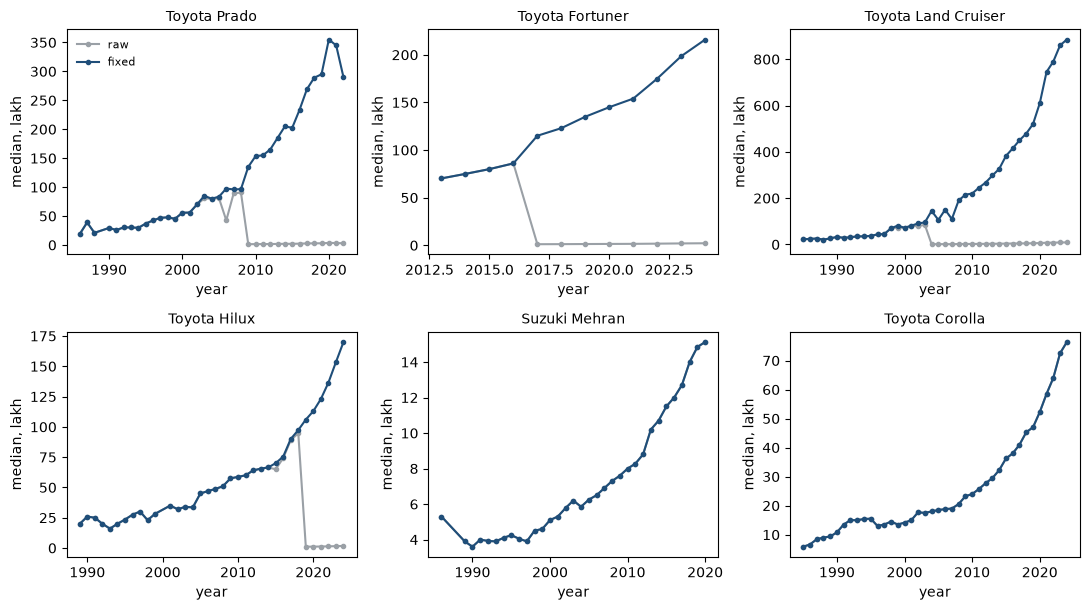

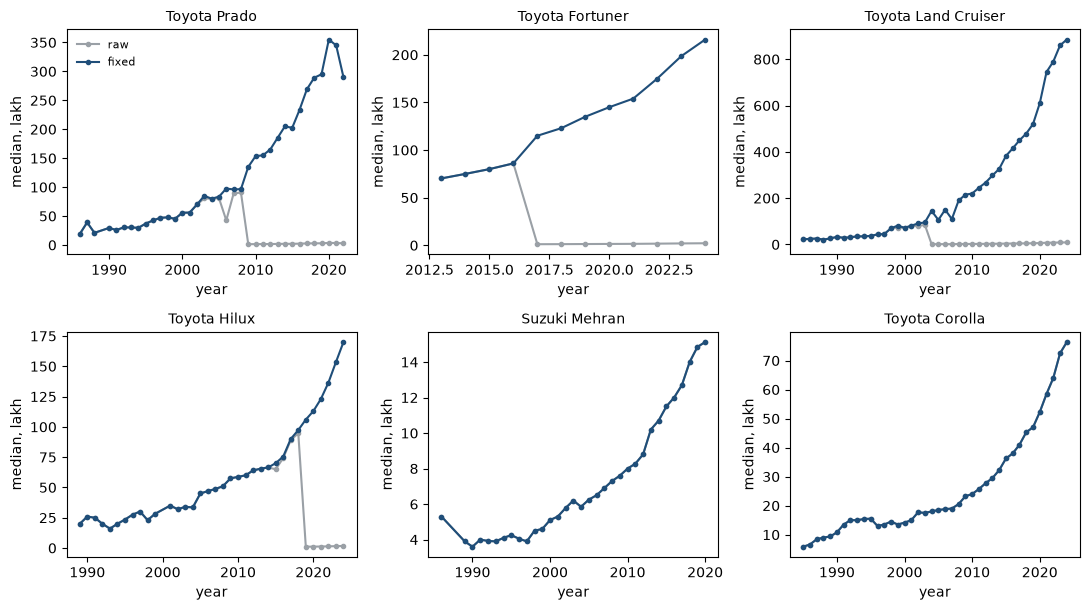

In [6]:
named = clean["make"] + " " + clean["model_name"]
show = [
    "Toyota Prado",
    "Toyota Fortuner",
    "Toyota Land Cruiser",
    "Toyota Hilux",
    "Suzuki Mehran",
    "Toyota Corolla",
]
fig, axes = plt.subplots(2, 3, figsize=(11, 6.2))
for ax, model in zip(axes.ravel(), show):
    part = clean.loc[named == model]
    grouped = part.groupby("year").agg(raw=("price", "median"), fixed=("price_lakh", "median"))
    ax.plot(grouped.index, grouped["raw"], color="#9aa0a6", marker="o", ms=3, label="raw")
    ax.plot(grouped.index, grouped["fixed"], color="#1f4e79", marker="o", ms=3, label="fixed")
    ax.set_title(model, fontsize=10)
    ax.set_xlabel("year")
    ax.set_ylabel("median, lakh")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.tight_layout()
fig


Prado, Fortuner, Land Cruiser, and the later Hilux years jump by about 100x once the crore readings are converted. Mehran and Corolla sit on top of their raw series, which is what we want: those cars were already in lakh. Budget makes (Suzuki, Daihatsu, FAW, Prince, United) have zero converted rows.

In [7]:
print("share of listings")
print((clean["make"].value_counts(normalize=True).head(8) * 100).round(1).to_string())
print()
print("fuel")
print(clean["fuel"].value_counts().to_string())

share of listings
make
Toyota        32.9
Suzuki        26.2
Honda         21.0
Daihatsu       4.9
Nissan         2.8
KIA            2.4
Hyundai        1.7
Mitsubishi     1.5

fuel
fuel
Petrol      45112
Hybrid       3638
Diesel       2025
CNG           417
Electric      223
LPG            51


Three makes are most of the market: Toyota about 33%, Suzuki about 26%, Honda about 21%. The rest are each under 5%. Fuel is more lopsided. Petrol is about 88% of cleaned rows, hybrid about 7%, diesel about 4%, and CNG, electric, and LPG together under 1.5%. A model that only chases overall MAE will look good while being weak on the thin slices.

In [8]:
pair = clean["make"] + " " + clean["model_name"]
counts = pair.value_counts()
print("make-model pairs", int(counts.size))
print("pairs with fewer than 20 listings", int((counts < 20).sum()))
print("km set to missing", int(clean["km"].isna().sum()))
print("engine cc missing", int(clean["engine_cc"].isna().sum()))
print("rows with a battery kWh", int(clean["battery_kwh"].notna().sum()))
print("year range", int(clean["year"].min()), int(clean["year"].max()))

make-model pairs 500
pairs with fewer than 20 listings 332
km set to missing 1613
engine cc missing 358
rows with a battery kWh 193
year range 1985 2024


About 332 of 500 make-model pairs have fewer than 20 listings. Those rare levels are collapsed to `Other` inside the training pipeline, fit on the training fold only, so the make is still used. Electric cars that stored kWh instead of cc keep that figure in `battery_kwh` and have a missing `engine_cc`.